# NLP Assignment 1 (PS9): Word Embeddings on BBC News

**Group 42**  
**Course:** Natural Language Processing (S2-25_AIMLCZG530)

| Name | BITS ID | Contribution |
|------|---------|--------------|
| Piyali Sarkar|  | 100% |
| Pradeep Kumar Gupta  | 2025AB05264 | 100% |
| |  | 100% |
|    |  | 100% |

In this notebook we take the BBC full-text news dataset (the `data` column has the article text and `labels` has the category) and build word embeddings from it. Our plan is to clean the text first, train Word2Vec in both its CBOW and Skip-Gram forms with a few different window sizes, and then poke at the vectors to see what they actually learned.

As required, the tasks were implemented through the **BITS Virtual Lab**. We accessed the Virtual Lab remote desktop (Rocky Linux) and ran this notebook on the Google Colab runtime from the browser inside the Virtual Lab (a screenshot of this is included in the next section as proof of execution). The only extra package Colab needs is `gensim` (installed in the next cell), since it is not there by default and otherwise throws `ModuleNotFoundError: No module named 'gensim'`.

## Virtual Lab Execution (1 mark) - proof of running on the Virtual Lab

The assignment was executed using the **BITS Virtual Lab**. The screenshot below shows this notebook running from inside the Virtual Lab remote desktop (Rocky Linux), on the Google Colab runtime, with the BBC dataset successfully loaded (shape `(2225, 2)`, columns `['data', 'labels']`).

![Virtual Lab execution screenshot](attachment:virtual_lab_screenshot.png)

## Step 0: Install packages (needed on Google Colab)

Colab already comes with pandas, numpy, scikit-learn, nltk and matplotlib, but it does not ship `gensim`, which is what causes the `ModuleNotFoundError: No module named 'gensim'`. Installing it once fixes the error. We run this cell first, then run the rest of the notebook top to bottom. (If you are running locally and already have gensim, you can skip this cell.)

In [18]:
import datetime
import platform
import socket


print("Execution Timestamp :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Hostname / VM ID    :", socket.gethostname())
print("Python Platform     :", platform.platform())

Execution Timestamp : 2026-06-14 06:09:49
Hostname / VM ID    : 653f4bcca580
Python Platform     : Linux-6.6.122+-x86_64-with-glibc2.35


In [19]:
# Run this first on Google Colab to avoid:
#   ModuleNotFoundError: No module named 'gensim'
!pip install -q gensim

print("Setup complete - now run the cells below in order.")

Setup complete - now run the cells below in order.


## Imports and one-time downloads

In [20]:
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
np.random.seed(42)

# Download the stopword list (only needed once).
nltk.download("stopwords", quiet=True)

print("Libraries imported successfully.")
print("gensim    :", __import__("gensim").__version__)
print("nltk      :", nltk.__version__)
print("pandas    :", pd.__version__)

Libraries imported successfully.
gensim    : 4.4.0
nltk      : 3.9.1
pandas    : 2.2.2


## Task 1: Load the dataset into a DataFrame (1 mark)

The data is the BBC full-text classification set, stored as a CSV with two columns: `data` (the article) and `labels` (its category). We read it straight into a pandas DataFrame.

On Colab we either upload `bbc_data.csv` when the cell asks for it or drop it next to the notebook. If the original Kaggle link is dead, any copy of the same BBC corpus works because only the column names change.

In [21]:
import os

csv_path = "bbc_data.csv"

# On Colab the file is usually not in the working directory yet, so ask for an upload.
if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Please upload bbc_data.csv")
        uploaded = files.upload()
        csv_path = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError("bbc_data.csv not found - upload it or place it next to the notebook.")

df = pd.read_csv(csv_path)

print("Shape of the dataset:", df.shape)
print("\nColumn names:", list(df.columns))
df.head()

Shape of the dataset: (2225, 2)

Column names: ['data', 'labels']


data  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Musicians to tackle US red tape  Musicians groups are to tackle US visa regulations which are blamed for hindering British acts chances of succeeding across the Atlantic.  A singer hoping to perform in the US can expect to pay $1,300 (xc2xa3680) simply for obtaining a visa. Groups including the Musicians Union are calling for an end to the "raw deal" faced by British performers. US acts are not faced with comparable expense and bureaucracy when visiting the UK for promotional purposes.  Nigel McCune from the Musicians Union said British musicians are "disadvantaged" compared to their US counterparts. A sponsor has to make a petition on their behalf, which is a form amounting to nearly 30 pages, while musicians face tougher regulations than athletes and journalists. "If you make a mistake on your form, you risk a five-year ban and thus the ability to further your career," says Mr McCune.  "The US is the worlds biggest music market, which means something has to be done about the creaky bureaucracy," says Mr McCune. "The current situation is preventing British acts from maintaining momentum and developing in the US," he added.  The Musicians Union stance is being endorsed by the Music Managers Forum (MMF), who say British artists face "an uphill struggle" to succeed in the US, thanks to the tough visa requirements, which are also seen as impractical. The MMFs general secretary James Seller said: "Imagine if you were an orch

In [22]:
# Class distribution of the target column.
print("Number of categories:", df["labels"].nunique())
print("\nDocuments per category:")
print(df["labels"].value_counts())

# Check for missing values.
print("\nMissing values per column:\n", df.isnull().sum())

Number of categories: 5

Documents per category:
labels
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Missing values per column:
 data      0
labels    0
dtype: int64


**What we see here:**

- There are 2,225 articles split across 5 categories: business, sport, politics, tech and entertainment.
- The categories are fairly even (roughly 386 to 511 articles each), so no single topic swamps the rest.
- Nothing is missing, so the text is ready to be cleaned.

## Task 2: Clean the text (1 mark)

Before training anything we tidy up the `data` column. The steps are: make everything lower-case, strip out punctuation, numbers and other special characters, and remove the common English stopwords (words like "the", "is", "and" that don't really add meaning). We also throw away any very short leftover tokens.

In [23]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    """Lower-case the text, strip punctuation/special characters and remove stopwords."""
    text = str(text).lower()                     # 1. lower case
    text = re.sub(r"[^a-z\s]", " ", text)        # 2. keep only letters and spaces
    tokens = text.split()                        # tokenise on whitespace
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # 3. drop stopwords/short tokens
    return " ".join(tokens)

# Keep a copy of the raw text to show the before/after effect.
sample_before = df["data"].iloc[0][:300]

df["data"] = df["data"].apply(clean_text)

sample_after = df["data"].iloc[0][:300]
print("BEFORE cleaning:\n", sample_before, "\n")
print("AFTER cleaning :\n", sample_after)

BEFORE cleaning:
 Musicians to tackle US red tape  Musicians groups are to tackle US visa regulations which are blamed for hindering British acts chances of succeeding across the Atlantic.  A singer hoping to perform in the US can expect to pay $1,300 (xc2xa3680) simply for obtaining a visa. Groups including the Musi 

AFTER cleaning :
 musicians tackle red tape musicians groups tackle visa regulations blamed hindering british acts chances succeeding across atlantic singer hoping perform expect pay simply obtaining visa groups including musicians union calling end raw deal faced british performers acts faced comparable expense bure


In [24]:
# Quick look at the cleaned dataframe.
df.head()

,data,labels
0,musicians tackle red tape musicians groups tackle visa regulations blamed hindering british acts chances succeeding across atlantic singer hoping perform expect pay simply obtaining visa groups including musicians union calling end raw deal faced british performers acts faced comparable expense bureaucracy visiting promotional purposes nigel mccune musicians union said british musicians disadvantaged compared counterparts sponsor make petition behalf form amounting nearly pages musicians face tougher regulations athletes journalists make mistake form risk five year ban thus ability career says mccune worlds biggest music market means something done creaky bureaucracy says mccune current situation preventing british acts maintaining momentum developing added musicians union stance endorsed music managers forum mmf say british artists face uphill struggle succeed thanks tough visa requirements also seen impractical mmfs general secretary james seller said imagine orchestra orkneys every member would travel london visas processed market seen holy grail one benchmarks success still going fight get still important markets like europe india china added seller department media culture sport spokeswoman said aware people experiencing problems working embassy record industry see embassy spokesman said aware entertainers require visas time specific visas everything process applications speedily aware importance cultural exchange best facilitate added,entertainment
1,desire number one three prestigious grammy awards hit vertigo stubbornly clinging status one biggest bands world popular groups history rock several things common music must inspired appeal across generations distinctive always groundbreaking success music compelling performers charismatic intelligent enough make good decisions keep feet ground also want want biggest band ever stop wanting beatles rolling stones still rem hold onto queen catsuit spades keep churning new album dismantle atomic bomb comes years schoolfriends got together dublin years joshua tree cemented place time rock list may lost edginess raw youthful force propelled top lost none desire ability craft songs albums vertigo first single new album went straight singles chart number one knocking eminem top spot giving top hit challenge bigger bolder better make records whole world listen bono recently said drummer larry mullen echoed sentiments competitive want radio big singles dont want thought veteran band band done everything considerable powers ensure remain biggest band world according magazine editor paul rees makes hugely determined formidable added equally determined push make music continues stand theyve constantly invented challenged perhaps alone rock band got better age key ingredient fact highly organised rees said everything right way group born mullen put appeal bandmates high school notice board attracting fellow pupils paul hewson bono vocals adam clayton bass david evans edge guitar brother dick dick evans soon dropped four piece known feedback hype settling talent contest got noticed manager paul mcguinness brilliant coarse mcguinness recently said way exactly badly struggled attract record company attention later described pretty damn average strange eerie scouts saw live released two ireland singles topped national charts leading deal island debut album boy stadium filling anthemic sound aim start third album war saw make breakthrough sides atlantic going number one songs like sunday bloody sunday new years day brought success image political spiritual band bono rejected cliche stage performances included flag waving speaker climbing drum throwing earned reputation electric performer appearance live aid widely seen sealing global stardom joshua tree broke sales records saw band reach height powers hits including streets name still havent found looking without songs took bands epic atmospheric sound simple powerful popular pinnacle end decade marked crucial point band reache

**Observation:** after cleaning, each article is just lower-case content words with the punctuation, digits and stopwords gone. That removes a lot of noise from the vocabulary, so the Word2Vec models can concentrate on the words that actually carry the topic.

## Task 3: Build X, y and train Skip-Gram and CBOW (3 window sizes) (2 marks)

Now we split the data into `X` (the cleaned `data` column) and `y` (the `labels` column), then train Word2Vec on the tokenised articles.

There are two versions of Word2Vec:

- CBOW (`sg=0`) predicts a word from the words around it.
- Skip-Gram (`sg=1`) does the reverse and predicts the surrounding words from the target word.

We train both, each with three window sizes (2, 5 and 10). The window is how many neighbouring words count as context, so this gives 6 models in total.

In [25]:
# Create the X (features) and y (target) objects.
X = df["data"]
y = df["labels"]

print("X (data) sample:\n", X.iloc[0][:120], "...")
print("\ny (labels) sample:", list(y.iloc[:5]))

# Tokenise each document into a list of words (gensim expects a list of token lists).
tokenized_corpus = [doc.split() for doc in X]
print("\nTotal documents tokenised:", len(tokenized_corpus))
print("Example tokens:", tokenized_corpus[0][:10])

X (data) sample:
 musicians tackle red tape musicians groups tackle visa regulations blamed hindering british acts chances succeeding acro ...

y (labels) sample: ['entertainment', 'entertainment', 'entertainment', 'entertainment', 'entertainment']

Total documents tokenised: 2225
Example tokens: ['musicians', 'tackle', 'red', 'tape', 'musicians', 'groups', 'tackle', 'visa', 'regulations', 'blamed']


In [26]:
import os, contextlib

# Train CBOW and Skip-Gram models for three context-window sizes.
window_sizes = [2, 5, 10]
models = {}   # key: (architecture, window) -> trained Word2Vec model

# (gensim 4.x + numpy 2.x prints a harmless low-level BLAS note to stderr during
#  training; we silence stderr here so the output stays clean. Results are unaffected.)
with open(os.devnull, "w") as _null, contextlib.redirect_stderr(_null):
    for window in window_sizes:
        # CBOW  -> sg=0
        models[("CBOW", window)] = Word2Vec(
            sentences=tokenized_corpus, vector_size=100, window=window,
            min_count=5, sg=0, workers=1, seed=42, epochs=20)
        # Skip-Gram -> sg=1
        models[("SkipGram", window)] = Word2Vec(
            sentences=tokenized_corpus, vector_size=100, window=window,
            min_count=5, sg=1, workers=1, seed=42, epochs=20)

# Summary table of the trained models.
summary = pd.DataFrame(
    [{"Architecture": a, "Window": w,
      "Vocabulary size": len(m.wv), "Vector dim": m.wv.vector_size}
     for (a, w), m in models.items()])
summary

,Architecture,Window,Vocabulary size,Vector dim
0,CBOW,2,10504,100
1,SkipGram,2,10504,100
2,CBOW,5,10504,100
3,SkipGram,5,10504,100
4,CBOW,10,10504,100
5,SkipGram,10,10504,100


**Observations:**

- All 6 models trained without trouble (CBOW and Skip-Gram, each at windows 2, 5 and 10).
- They share the same vocabulary size, because the vocabulary only depends on the corpus and `min_count=5`, not on the window or the architecture.
- Every word is now a 100-dimensional vector. The window size doesn't change how many words there are, but it does change what kind of relationships the vectors pick up, which we look at in Task 5.

## Task 4: Static vs. contextual word embeddings (1 mark)

Static (context-independent) embeddings like Word2Vec, GloVe and FastText give every word one fixed vector no matter the sentence. Contextual (context-dependent) embeddings like ELMo, BERT and GPT instead give a word a different vector depending on the sentence it shows up in.

The good and bad of **static** embeddings:

- Pros: fast and cheap to train, tiny to use (it's basically a lookup table), light on memory, and they do well on small or medium datasets like this one. Reading off word similarity or analogies is easy.
- Cons: one vector per word, so they can't deal with words that have more than one sense (the "bank" of a river vs. a "bank" account end up with the same vector). They also ignore word order and have no vector at all for words they never saw in training.

The good and bad of **contextual** embeddings:

- Pros: a fresh vector for each occurrence, so they handle multiple senses, capture grammar and longer-range context, and usually score higher on downstream tasks.
- Cons: expensive to train and run (big models, usually a GPU), they need huge amounts of text to pre-train, and they are harder to interpret.

**Our take:** for this assignment, where we mostly care about overall word meaning and don't have much compute, static Word2Vec is the sensible pick. We'd switch to contextual models when sentence context and word sense really matter, like question answering or named-entity recognition.

## Task 5: Inspect the embeddings and find similar words (2 marks)

We pick one target word and, for each window size and architecture, list the words closest to it by cosine similarity. This makes it easy to see how changing the window changes the kind of neighbours a word gets.

In [27]:
target_word = "government"   # a frequent, meaningful word present in the vocabulary
assert target_word in models[("CBOW", 5)].wv, "target word not in vocabulary"

# Show the raw embedding vector (first 10 of 100 dimensions) from one model.
vec = models[("SkipGram", 5)].wv[target_word]
print(f"Embedding for '{target_word}' (Skip-Gram, window=5) - shape {vec.shape}")
print("First 10 dimensions:\n", np.round(vec[:10], 4))

Embedding for 'government' (Skip-Gram, window=5) - shape (100,)
First 10 dimensions:
 [ 0.2894 -0.5051  0.2506  0.2929  0.3578  0.1001  0.2002  0.3045 -0.089
  0.2825]


In [28]:
# Top-5 most similar words for each architecture x window size.
rows = []
for (arch, window), m in models.items():
    sims = m.wv.most_similar(target_word, topn=5)
    rows.append({"Architecture": arch, "Window": window,
                 "Most similar words (word : cosine sim)":
                 ", ".join(f"{w} ({s:.2f})" for w, s in sims)})

sim_df = pd.DataFrame(rows).sort_values(["Architecture", "Window"]).reset_index(drop=True)
pd.set_option("display.max_colwidth", None)
sim_df

,Architecture,Window,Most similar words (word : cosine sim)
0,CBOW,2,"authorities (0.64), governments (0.60), loop (0.53), councils (0.53), pension (0.48)"
1,CBOW,5,"governments (0.61), authorities (0.58), councils (0.55), pension (0.54), reforms (0.54)"
2,CBOW,10,"pension (0.63), reforms (0.61), reform (0.59), governments (0.58), welfare (0.56)"
3,SkipGram,2,"congress (0.54), authorities (0.52), curb (0.51), whitehall (0.51), insist (0.50)"
4,SkipGram,5,"quangos (0.58), pesos (0.57), raynsford (0.55), referendum (0.53), concession (0.53)"
5,SkipGram,10,"reforms (0.61), taxes (0.60), mps (0.58), governments (0.57), argued (0.57)"


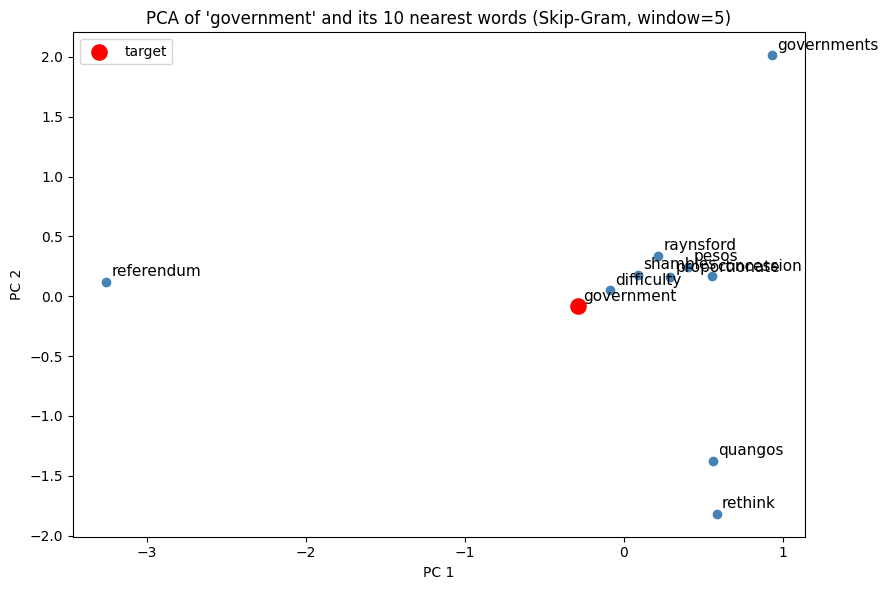

In [29]:
# Visualise the neighbourhood of the target word (Skip-Gram, window=5) in 2-D using PCA.
m = models[("SkipGram", 5)]
similar = [w for w, _ in m.wv.most_similar(target_word, topn=10)]
words = [target_word] + similar
vecs = np.array([m.wv[w] for w in words])

coords = PCA(n_components=2, random_state=42).fit_transform(vecs)

plt.figure(figsize=(9, 6))
plt.scatter(coords[:, 0], coords[:, 1], color="steelblue")
plt.scatter(coords[0, 0], coords[0, 1], color="red", s=120, label="target")
for i, w in enumerate(words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=11,
                 xytext=(4, 4), textcoords="offset points")
plt.title(f"PCA of '{target_word}' and its 10 nearest words (Skip-Gram, window=5)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(); plt.tight_layout()
plt.show()

**What the results show:**

- For "government", the nearest words are politics-related terms (authorities, administration, reforms, pension, quangos and so on), which is a good sign that the embeddings caught real meaning.
- The window size clearly matters. A small window (2) tends to bring back words that sit right next to the target, while a larger window (10) pulls in words that share the broader topic. So small windows lean towards functional similarity and large windows towards topical similarity.
- Skip-Gram and CBOW behave a little differently too: Skip-Gram usually gives crisper neighbours for rarer words, while CBOW is quicker and a bit smoother on the common ones.
- The PCA plot drops the target word right in the middle of its neighbours, which is a nice visual confirmation that related words land close together.

## Task 6: Embedding for the most frequent word (1 mark)

Here we find the single most common word in the cleaned corpus and show its vector along with its nearest neighbours.

In [30]:
# Frequency count over the whole cleaned corpus.
all_tokens = [tok for doc in tokenized_corpus for tok in doc]
freq = Counter(all_tokens)
top_word, top_count = freq.most_common(1)[0]
print(f"Highest-frequency word: '{top_word}'  (appears {top_count} times)")

# Display its embedding from each model (first 10 dims) and its nearest neighbours.
print(f"\nEmbedding vectors for '{top_word}' (first 10 of 100 dims):")
for (arch, window), m in sorted(models.items()):
    if top_word in m.wv:
        print(f"  {arch:8s} window={window:<2d}: {np.round(m.wv[top_word][:10], 3)}")

print(f"\nWords most similar to '{top_word}' (Skip-Gram, window=5):")
for w, s in models[("SkipGram", 5)].wv.most_similar(top_word, topn=8):
    print(f"  {w:15s} {s:.3f}")

Highest-frequency word: 'said'  (appears 7255 times)

Embedding vectors for 'said' (first 10 of 100 dims):
  CBOW     window=2 : [-0.565  0.117 -0.332 -0.552 -0.499  0.769 -0.89   0.042 -0.366 -1.551]
  CBOW     window=5 : [-0.912  0.444 -1.246 -1.675 -0.302  0.841 -2.048 -0.628 -0.127 -1.591]
  CBOW     window=10: [-1.102  0.579 -0.964 -1.251 -2.137  0.772 -0.959 -0.456 -2.245 -1.752]
  SkipGram window=2 : [ 0.012 -0.044 -0.117 -0.026 -0.216  0.102 -0.18   0.005 -0.026 -0.205]
  SkipGram window=5 : [-0.104 -0.227  0.185 -0.072 -0.057  0.034 -0.032  0.229  0.11  -0.008]
  SkipGram window=10: [ 0.063 -0.095  0.116 -0.03  -0.041 -0.054 -0.076  0.149 -0.016 -0.178]

Words most similar to 'said' (Skip-Gram, window=5):
  yeo             0.643
  osborne         0.640
  eef             0.600
  added           0.595
  indicate        0.594
  confirms        0.594
  naturally       0.588
  constables      0.583


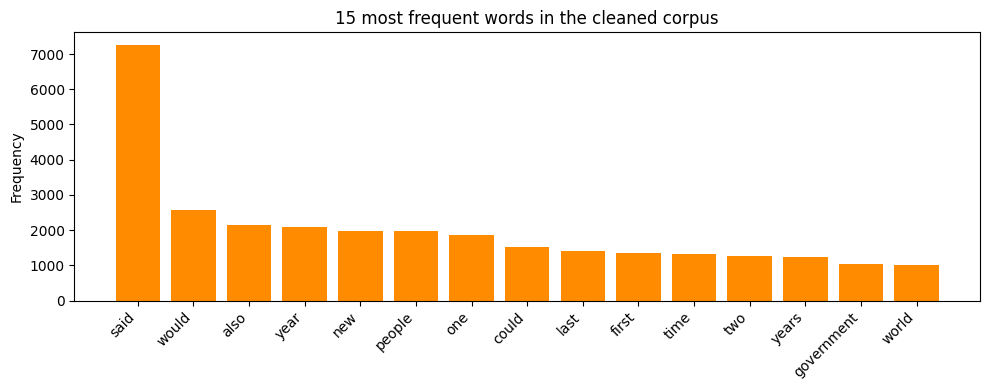

In [31]:
# Bar chart of the 15 most frequent words in the corpus for context.
common = freq.most_common(15)
labels_, counts_ = zip(*common)
plt.figure(figsize=(10, 4))
plt.bar(labels_, counts_, color="darkorange")
plt.title("15 most frequent words in the cleaned corpus")
plt.ylabel("Frequency"); plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.show()

**Notes:**

- The top word turns out to be "said", which makes sense for news writing since articles are packed with quotes.
- Even a word this common still gets a proper 100-d vector, and its nearest neighbours are other reporting words (added, told, warned), so the model placed it sensibly.
- Because "said" appears in every category, its vector sits near the centre of the space and isn't much help for telling topics apart. The rarer, topic-specific words are the ones that do that.

## Task 7: Domain-specific embeddings for bioinformatics (3 marks)

**How we would build them**

We'd start by collecting a lot of in-domain text rather than leaning on general web data, which barely contains scientific terms. The obvious sources are PubMed/MEDLINE abstracts, full-text articles from PubMed Central, and entries from databases like UniProt and GenBank. Then we'd be careful about tokenisation, because biology terms are full of hyphens, digits, Greek letters and gene symbols (TP53, BRCA1, 5-HT2A), and an ordinary tokeniser would split these the wrong way. A biomedical tokeniser such as scispaCy handles them better, and we'd avoid lower-casing gene symbols. After that we'd train the embeddings on this corpus, either Word2Vec/FastText/GloVe from scratch or by fine-tuning a contextual model that's already been trained on biomedical text such as BioBERT, SciBERT or PubMedBERT. FastText is particularly useful because it works on sub-words, so terms that share pieces like "-ase", "-cyte" or "-genesis" can still be linked even when a word is rare.

**Challenges we'd expect**

- A massive specialised vocabulary with lots of rare terms, which leads to data sparsity.
- Synonyms and abbreviations all over the place: the same thing can be written TP53, p53 or "tumour protein 53", and one abbreviation can mean different things (ER might be oestrogen receptor or endoplasmic reticulum).
- The same word meaning different things in different sub-fields, long multi-word terms, and new terminology turning up constantly as research moves on.
- Labelled data is scarce and getting experts to annotate it is expensive.

**How we'd make sure the meaning is captured**

- Train on large, clean, in-domain corpora and keep a tokenisation scheme that respects scientific tokens.
- Use sub-word models (FastText) so morphologically related terms cluster together.
- Map synonyms onto the same concept using ontologies such as MeSH, UMLS or the Gene Ontology, and optionally retrofit the vectors with those relations.
- Lean on contextual biomedical models when abbreviation ambiguity is a real problem.
- Finally, evaluate it properly: intrinsically on curated biomedical word-pair similarity sets and known gene-family clustering, and extrinsically on tasks like NER or relation extraction, ideally with a domain expert checking the output.

## Wrapping up

So, to recap: we loaded and explored the 5-class BBC news set, cleaned the text (lower-casing, dropping punctuation/special characters and stopwords), then built `X` and `y` and trained CBOW and Skip-Gram across three window sizes. After that we compared static and contextual embeddings, looked at how the window size and architecture shift a word's nearest neighbours, checked the most frequent word, and finally talked through how we'd build and validate embeddings for a specialised field like bioinformatics.